In [1]:
import numpy as np
import math
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Question 5

In [2]:
# Parameters
sigma = 10.0
rho   = 28.0
beta  = 8.0/3.0 

#Fixed Points
P0 = np.array([0.0, 0.0, 0.0])
r = math.sqrt(beta*(rho - 1))
P1 = np.array([ r,  r, rho - 1])
P2 = np.array([-r, -r, rho - 1])

#Jacobians
J0 = np.array([
    [-sigma,  sigma, 0],
    [ rho,    -1,    0],
    [   0,     0, -beta]
], float)

J1 = np.array([
    [-sigma,   sigma,    0],
    [rho-(rho-1), -1,    -P1[0]],
    [P1[1],      P1[0],  -beta]
], float)

J2 = np.array([
    [-sigma,   sigma,    0],
    [rho-(rho-1), -1,    -P2[0]],
    [P2[1],      P2[0],  -beta]
], float)

#Eigenvalues calculation
eigs_J0 = np.linalg.eigvals(J0)
eigs_Jp = np.linalg.eigvals(J1)
eigs_Jm = np.linalg.eigvals(J2)

print("Fixed point P0 =", P0)
print("Jacobian at P0:\n", J0)
print("Eigenvalues of J0:", eigs_J0, "\n")

print("Fixed point P+ =", P1)
print("Jacobian at P+:\n", J1)
print("Eigenvalues of J+:", eigs_Jp, "\n")

print("Fixed point P- =", P2)
print("Jacobian at P-:\n", J2)
print("Eigenvalues of J-:", eigs_Jm)

Fixed point P0 = [0. 0. 0.]
Jacobian at P0:
 [[-10.          10.           0.        ]
 [ 28.          -1.           0.        ]
 [  0.           0.          -2.66666667]]
Eigenvalues of J0: [-22.82772345  11.82772345  -2.66666667] 

Fixed point P+ = [ 8.48528137  8.48528137 27.        ]
Jacobian at P+:
 [[-10.          10.           0.        ]
 [  1.          -1.          -8.48528137]
 [  8.48528137   8.48528137  -2.66666667]]
Eigenvalues of J+: [-13.85457791 +0.j           0.09395562+10.19450522j
   0.09395562-10.19450522j] 

Fixed point P- = [-8.48528137 -8.48528137 27.        ]
Jacobian at P-:
 [[-10.          10.           0.        ]
 [  1.          -1.           8.48528137]
 [ -8.48528137  -8.48528137  -2.66666667]]
Eigenvalues of J-: [-13.85457791 +0.j           0.09395562+10.19450522j
   0.09395562-10.19450522j]


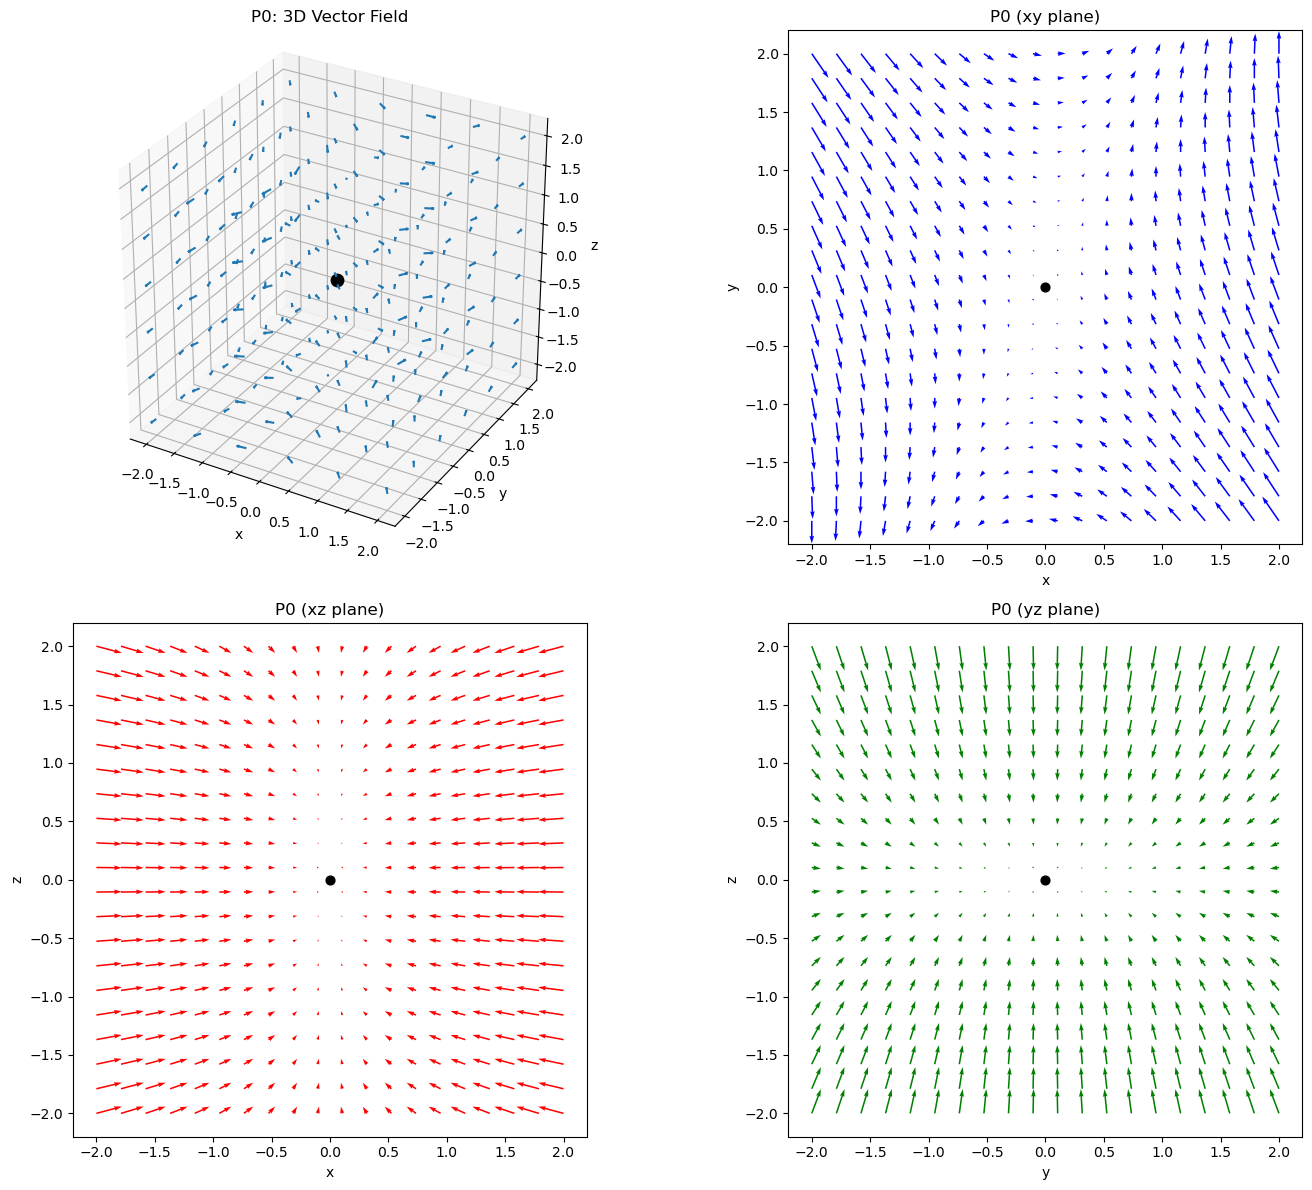

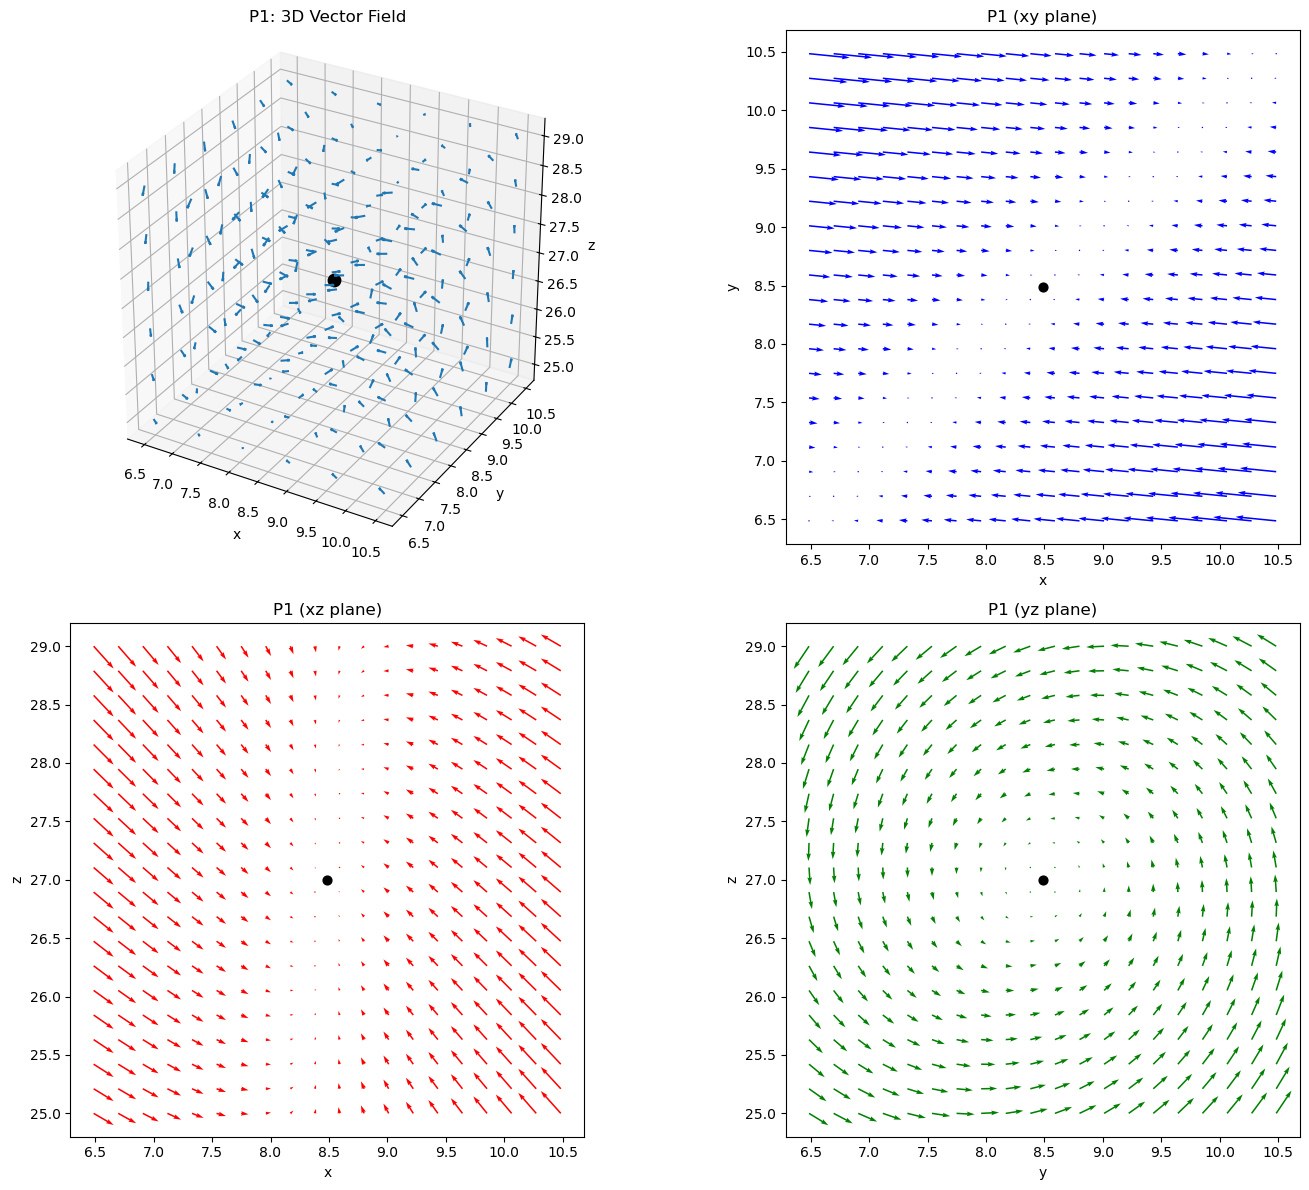

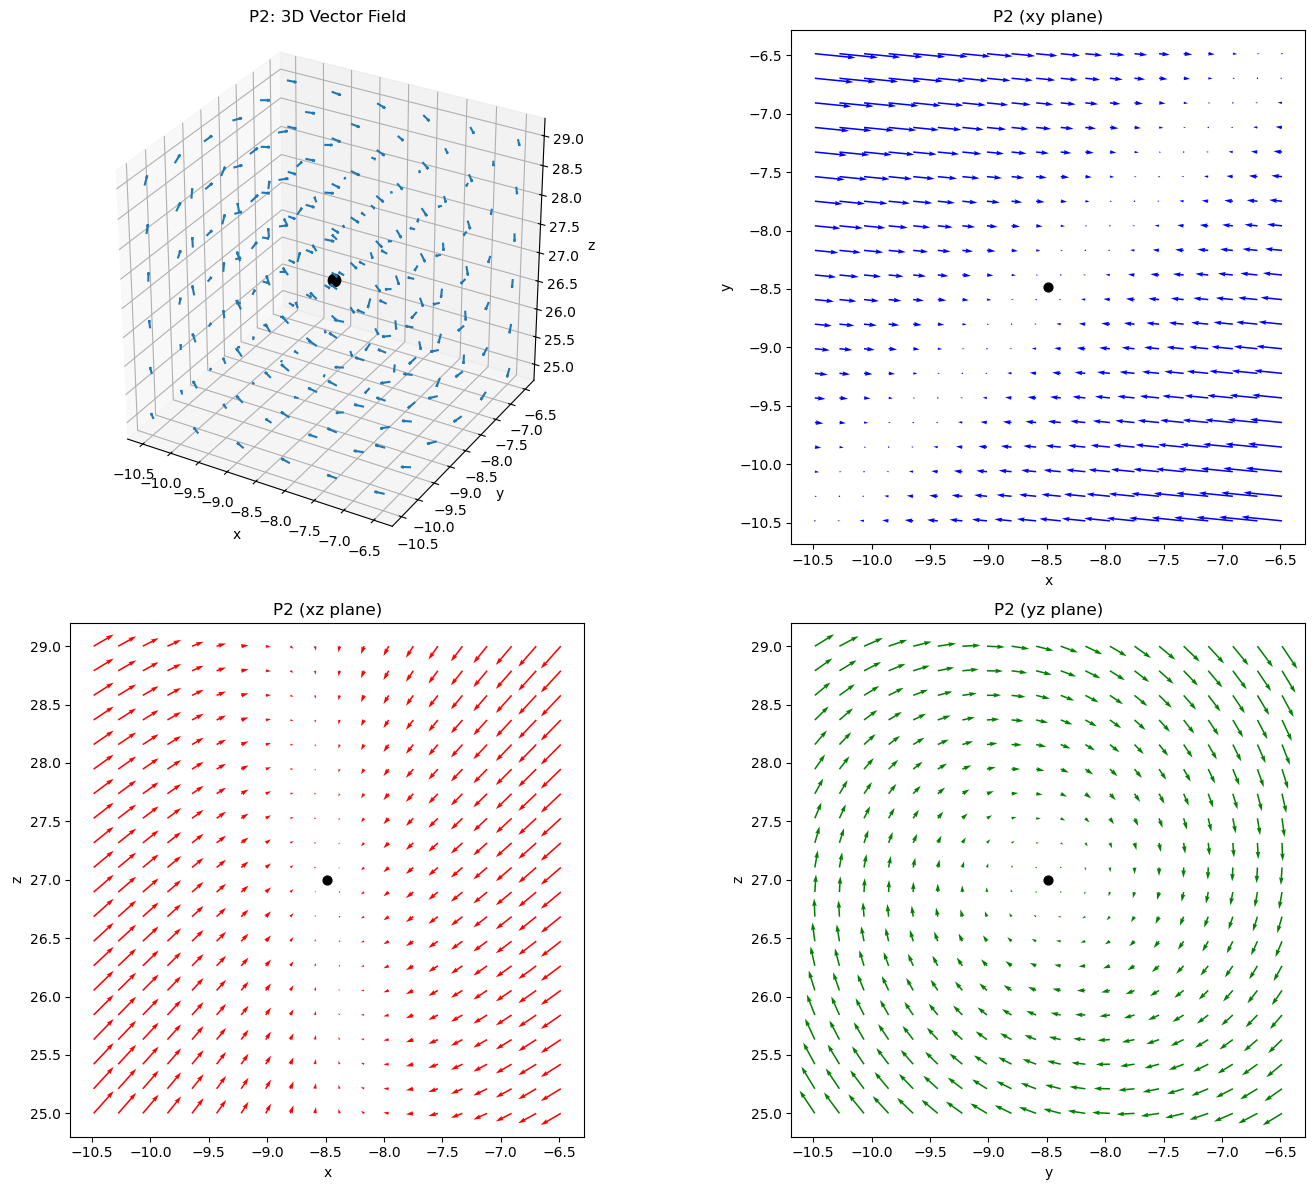

In [3]:
# Linearized vector field
def linear_vec_field(X, Y, Z, J, P):
    pts = np.stack([X - P[0], Y - P[1], Z - P[2]], axis=-1)
    V = pts @ J.T
    return V[...,0], V[...,1], V[...,2]


# 3D Vector Field
def plot_3d_field(J, P, ax, title):
    span = 2.0
    N = 6
    x = np.linspace(P[0]-span, P[0]+span, N)
    y = np.linspace(P[1]-span, P[1]+span, N)
    z = np.linspace(P[2]-span, P[2]+span, N)
    X, Y, Z = np.meshgrid(x, y, z)

    U, V, W = linear_vec_field(X, Y, Z, J, P)

    ax.quiver(X, Y, Z, U, V, W, length=0.15, normalize=True)
    ax.scatter(*P, color='black', s=80)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect([1,1,1])

# Generic 2D slice plotter
def plot_2d_slice(J, P, ax, plane="xy", title=""):
    span = 2.0
    N = 20
    x = np.linspace(P[0]-span, P[0]+span, N)
    y = np.linspace(P[1]-span, P[1]+span, N)
    z = np.linspace(P[2]-span, P[2]+span, N)

    if plane == "xy":
        X, Y = np.meshgrid(x, y)
        Z = np.full_like(X, P[2])
        U, V, _ = linear_vec_field(X, Y, Z, J, P)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    elif plane == "xz":
        X, Z = np.meshgrid(x, z)
        Y = np.full_like(X, P[1])
        U, _, W = linear_vec_field(X, Y, Z, J, P)
        ax.set_xlabel("x")
        ax.set_ylabel("z")

    elif plane == "yz":
        Y, Z = np.meshgrid(y, z)
        X = np.full_like(Y, P[0])
        _, V, W = linear_vec_field(X, Y, Z, J, P)
        ax.set_xlabel("y")
        ax.set_ylabel("z")

    # Pick the correct component pair
    if plane == "xy":
        ax.quiver(X, Y, U, V, color="blue")
        ax.scatter(P[0], P[1], color="black", s=40)

    elif plane == "xz":
        ax.quiver(X, Z, U, W, color="red")
        ax.scatter(P[0], P[2], color="black", s=40)

    elif plane == "yz":
        ax.quiver(Y, Z, V, W, color="green")
        ax.scatter(P[1], P[2], color="black", s=40)

    ax.set_aspect("equal")
    ax.set_title(title + f" ({plane} plane)")

# Master plotting function for one equilibrium point
def plot_all_views(J, P, name="Fixed Point"):
    fig = plt.figure(figsize=(15, 12))

    # 3D View
    ax3d = fig.add_subplot(2, 2, 1, projection='3d')
    plot_3d_field(J, P, ax3d, f"{name}: 3D Vector Field")

    # x–y
    ax_xy = fig.add_subplot(2, 2, 2)
    plot_2d_slice(J, P, ax_xy, plane="xy", title=f"{name}")

    # x–z
    ax_xz = fig.add_subplot(2, 2, 3)
    plot_2d_slice(J, P, ax_xz, plane="xz", title=f"{name}")

    # y–z
    ax_yz = fig.add_subplot(2, 2, 4)
    plot_2d_slice(J, P, ax_yz, plane="yz", title=f"{name}")

    plt.tight_layout()
    plt.show()

plot_all_views(J0, P0, "P0")
plot_all_views(J1, P1, "P1")
plot_all_views(J2, P2, "P2")

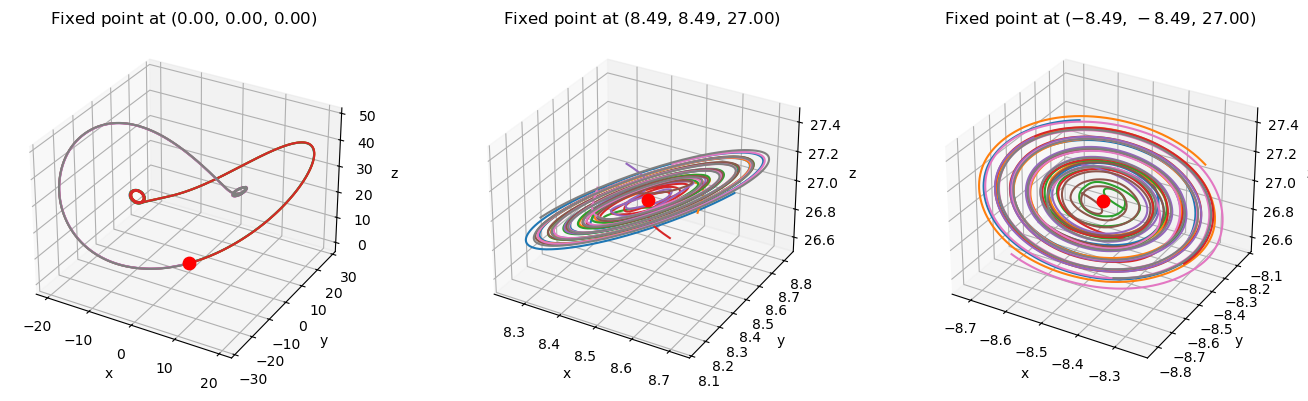

In [4]:
# Lorenz ODE
def lorenz(t, X):
    x, y, z = X
    return np.array([
        sigma*(y - x),
        x*(rho - z) - y,
        x*y - beta*z
    ])

# Numerical Integration
def simulate(x0, dt=0.001, steps=3000):
    t_span = (0, dt * (steps - 1))
    t_eval = np.linspace(t_span[0], t_span[1], steps)

    # Solve ODE
    sol = solve_ivp(
        lorenz,
        t_span,
        x0,
        t_eval=t_eval
    )

    return sol.y.T

# Phase portrait plots
fig = plt.figure(figsize=(14, 4))

fixed_points=[P0,P1,P2]
for i, fp in enumerate(fixed_points, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')

    title_latex = rf"Fixed point at $({fp[0]:.2f},\, {fp[1]:.2f},\, {fp[2]:.2f})$"
    ax.set_title(title_latex, fontsize=12)

    #Bundle of Trajectories
    for dx in [0.1, -0.1]:
        for dy in [0.1, -0.1]:
            for dz in [0.1, -0.1]:
                x0 = fp + np.array([dx, dy, dz])
                traj = simulate(x0)
                ax.plot(traj[:, 0], traj[:, 1], traj[:, 2])

    ax.scatter(fp[0], fp[1], fp[2], c='red', s=80)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
plt.tight_layout()
plt.show()

Question 6

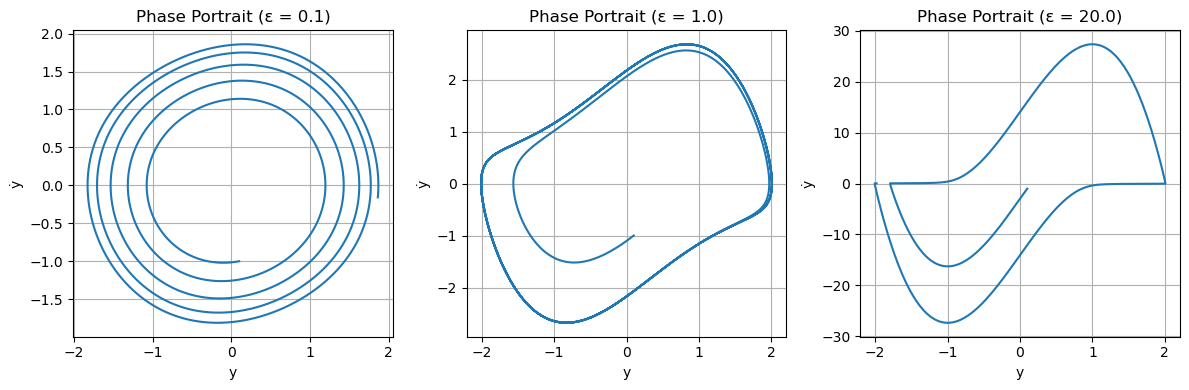

In [5]:
# Van der Pol system
def vdp(t, x, eps):
    y, ydot = x
    return [ydot, -y - eps*(y**2 - 1)*ydot]

# Numerical Integration
def solve_vdp(eps, y0, ydot0, t_end=30, dt=0.001):
    t_eval = np.arange(0, t_end + dt, dt)
    sol = solve_ivp(
        vdp, 
        [0, t_end], 
        [y0, ydot0], 
        method='RK45',
        t_eval=t_eval, 
        args=(eps,),
        rtol=1e-8, atol=1e-10
    )
    return sol.t, sol.y.T

# Parameters
eps_values = [0.1, 1.0, 20.0]
y0, ydot0 = 0.1, -1.0

# Plot phase portraits
plt.figure(figsize=(12, 4))

for i, eps in enumerate(eps_values):
    t, sol = solve_vdp(eps, y0, ydot0)

    plt.subplot(1, 3, i+1)
    plt.plot(sol[:,0], sol[:,1])
    plt.xlabel("y")
    plt.ylabel("ẏ")
    plt.title(f"Phase Portrait (ε = {eps})")
    plt.grid(True)

plt.tight_layout()
plt.show()

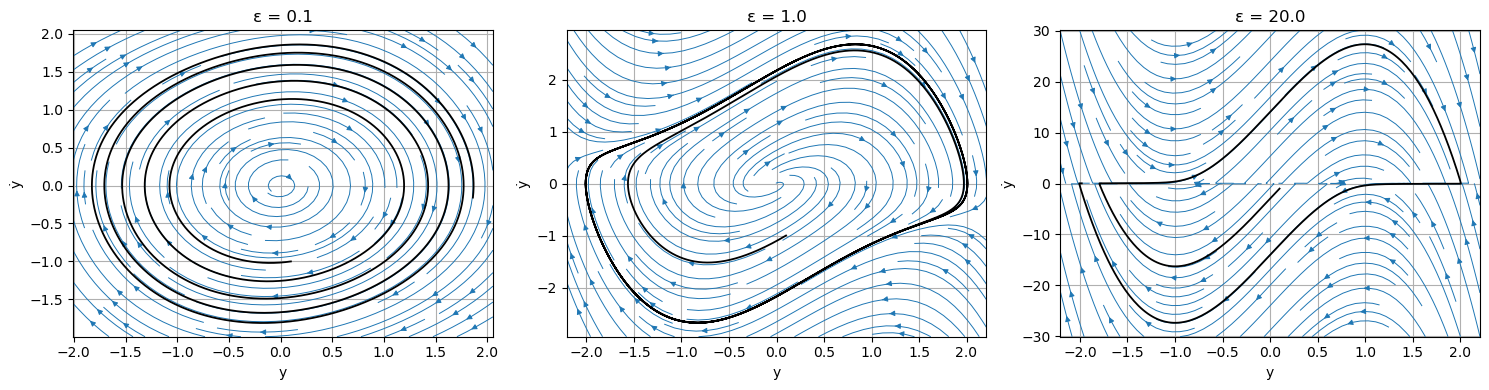

In [6]:
# Van der Pol system
def vdp(t, x, eps):
    y, ydot = x
    return [ydot, -y - eps*(y**2 - 1)*ydot]

# Numerical Integration
def solve_vdp(eps, y0, ydot0, t_end=30, dt=0.001):
    t_eval = np.arange(0, t_end + dt, dt)
    sol = solve_ivp(
        vdp,
        [0, t_end],
        [y0, ydot0],
        method="RK45",
        t_eval=t_eval,
        args=(eps,),
        rtol=1e-8, atol=1e-10
    )
    return sol.t, sol.y.T

# Parameters
eps_values = [0.1, 1.0, 20.0]
y0, ydot0 = 0.1, -1.0

plt.figure(figsize=(15, 4))

for i, eps in enumerate(eps_values):

    # Solve ODE
    t, sol = solve_vdp(eps, y0, ydot0)
    y_sol  = sol[:,0]
    yd_sol = sol[:,1]
    ax = plt.subplot(1, 3, i+1)

    y_min, y_max   = np.min(y_sol), np.max(y_sol)
    yd_min, yd_max = np.min(yd_sol), np.max(yd_sol)
    
    y_vals  = np.linspace(y_min  - 0.1*abs(y_min),  y_max  + 0.1*abs(y_max),  60)
    yd_vals = np.linspace(yd_min - 0.1*abs(yd_min), yd_max + 0.1*abs(yd_max), 60)

    Y, YD = np.meshgrid(y_vals, yd_vals)

    # Vector field
    U = YD
    V = -Y - eps*(Y**2 - 1)*YD

    # Normalize
    mag = np.sqrt(U**2 + V**2)
    U /= mag
    V /= mag

    ax.streamplot(y_vals, yd_vals, U, V,
                  density=1.2, linewidth=0.7, arrowsize=0.8)

    # Trajectory
    ax.plot(y_sol, yd_sol, color='k', lw=1.3)

    ax.set_xlabel("y")
    ax.set_ylabel("ẏ")
    ax.set_title(f"ε = {eps}")
    ax.grid(True)

plt.tight_layout()
plt.show()